# Step 1: Import Required Libraries

In this step, we import all the libraries required for data analysis, visualization, preprocessing, machine learning, and time series forecasting.

- **Pandas** for data manipulation.
- **NumPy** for numerical operations.
- **Matplotlib & Seaborn** for visualization.
- **Scikit-learn** for preprocessing and machine learning.
- **Statsmodels** for time series forecasting.

In [ ]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import time series forecasting model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

# Step 2: Load the Dataset

The Tesla deliveries dataset is loaded into a Pandas DataFrame. This dataset contains historical vehicle delivery information which will be analyzed and used for prediction.

In [ ]:
# Load Tesla deliveries dataset

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

# Display first 5 records

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Step 3: Explore Dataset Dimensions

This step checks the number of rows and columns present in the dataset to understand its overall size.

In [ ]:
# Display dataset shape

print("Dataset Shape:", df.shape)

# Display column information

df.info()

# Statistical summary

df.describe()

Dataset Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Step 4: Check Missing Values

The dataset is examined for missing values in each column. Identifying missing data is important before performing any analysis or model training.

In [ ]:
# Check missing values in each column

df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


# Step 5: Handle Missing Values

Missing values are filled using the Forward Fill (ffill) technique, where each missing value is replaced with the previous valid observation.

In [ ]:
# Fill missing values using forward fill method

df.fillna(method='ffill', inplace=True)

# Verify missing values

df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


# Step 6: Identify Duplicate Records

Duplicate rows are counted to determine whether repeated observations exist in the dataset.

In [ ]:
# Count duplicate rows

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


# Step 7: Remove Duplicate Records

Duplicate records are removed to improve data quality and prevent bias during model training.

In [ ]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

# Verify dataset shape

print("Updated Shape:", df.shape)

Updated Shape: (2640, 12)


# Step 8: Visualize Data Distribution

Histograms are plotted to understand the distribution of numerical variables and identify skewness or unusual patterns.

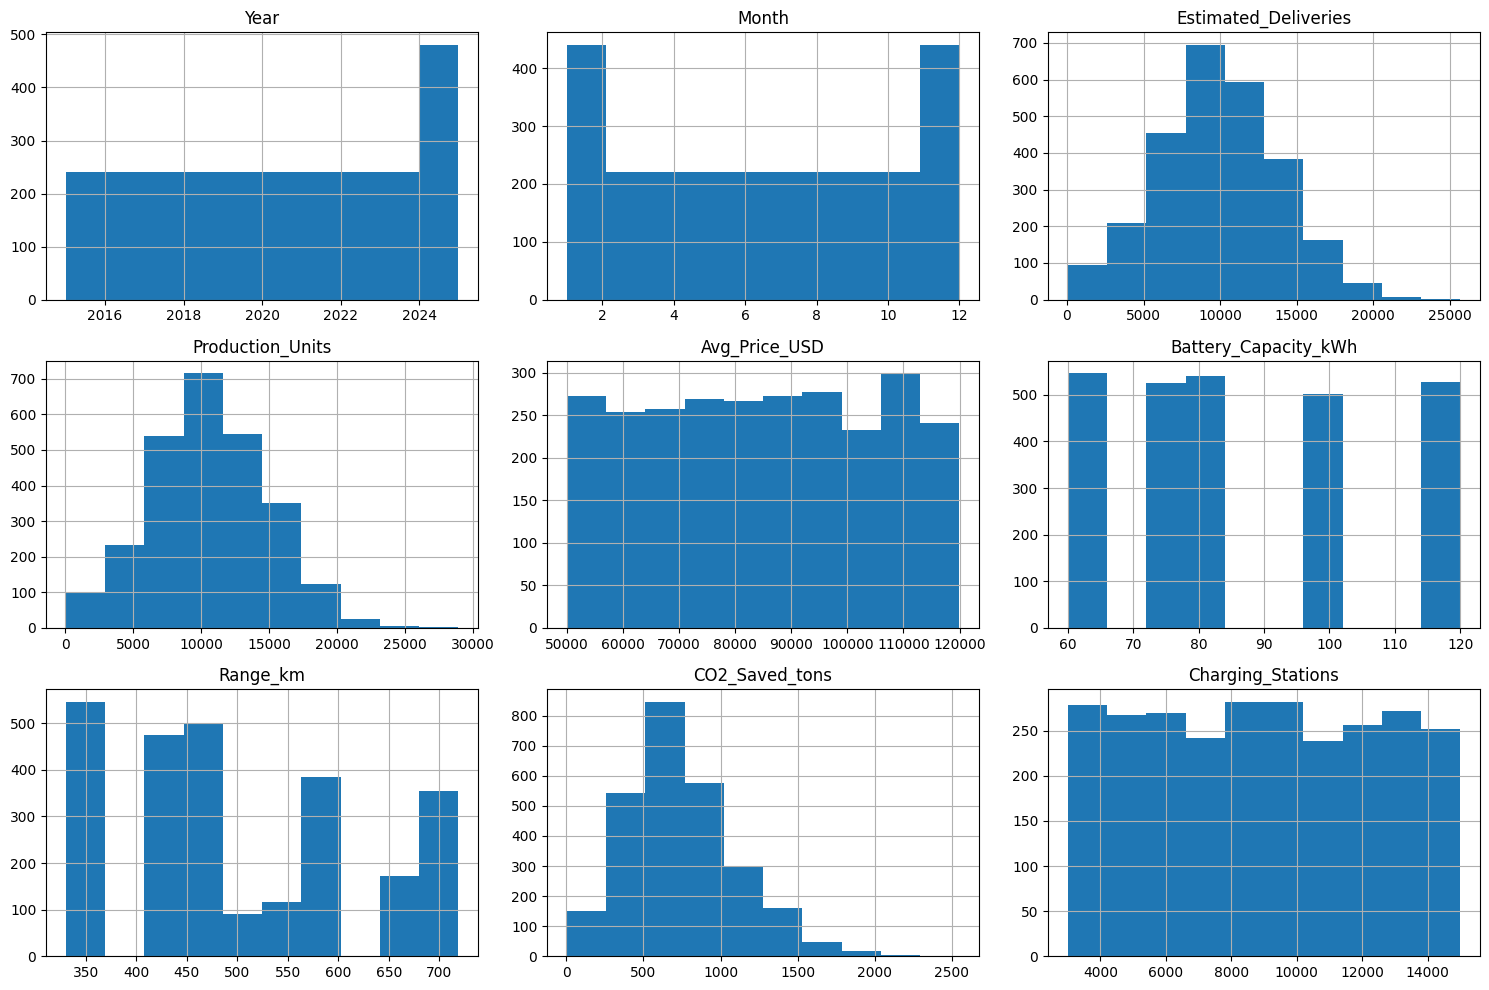

In [ ]:
# Visualize distribution of numerical columns

df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

# Step 9: Analyze Delivery Trends

A line chart is created to visualize how Tesla deliveries have changed over time and identify overall trends.

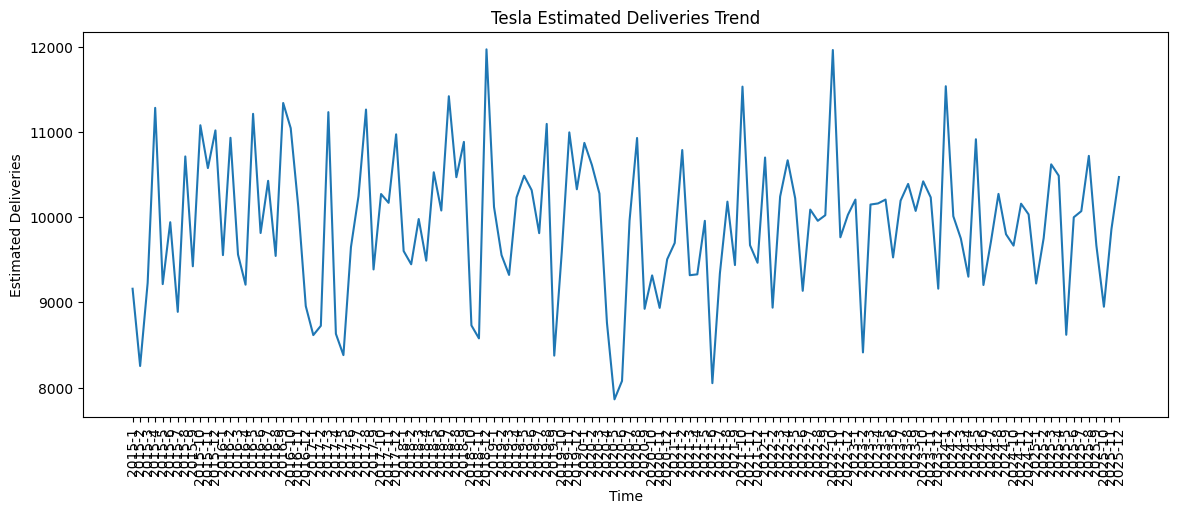

In [ ]:
# Analyze delivery trend over time

monthly = df.groupby(
    ['Year','Month']
)['Estimated_Deliveries'].mean().reset_index()

# Create time period column

monthly['Period'] = (
    monthly['Year'].astype(str)
    + '-'
    + monthly['Month'].astype(str)
)

plt.figure(figsize=(14,5))

plt.plot(
    monthly['Period'],
    monthly['Estimated_Deliveries']
)

plt.title("Tesla Estimated Deliveries Trend")

plt.xlabel("Time")

plt.ylabel("Estimated Deliveries")

plt.xticks(rotation=90)

plt.show()

# Step 10: Detect Outliers

Boxplots are used to identify outliers in the delivery data. Outliers can influence model performance and statistical analysis.

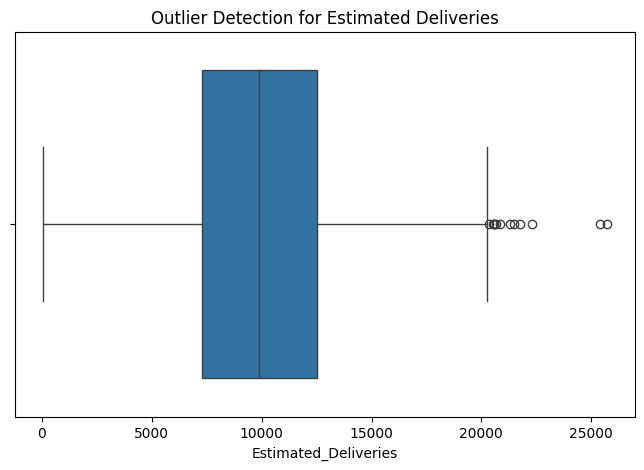

In [ ]:
# Detect outliers in delivery values

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Estimated_Deliveries']
)

plt.title("Outlier Detection for Estimated Deliveries")

plt.show()

# Step 11: Correlation Analysis

A correlation matrix is generated to understand relationships between numerical variables. Highly correlated features may influence model performance.

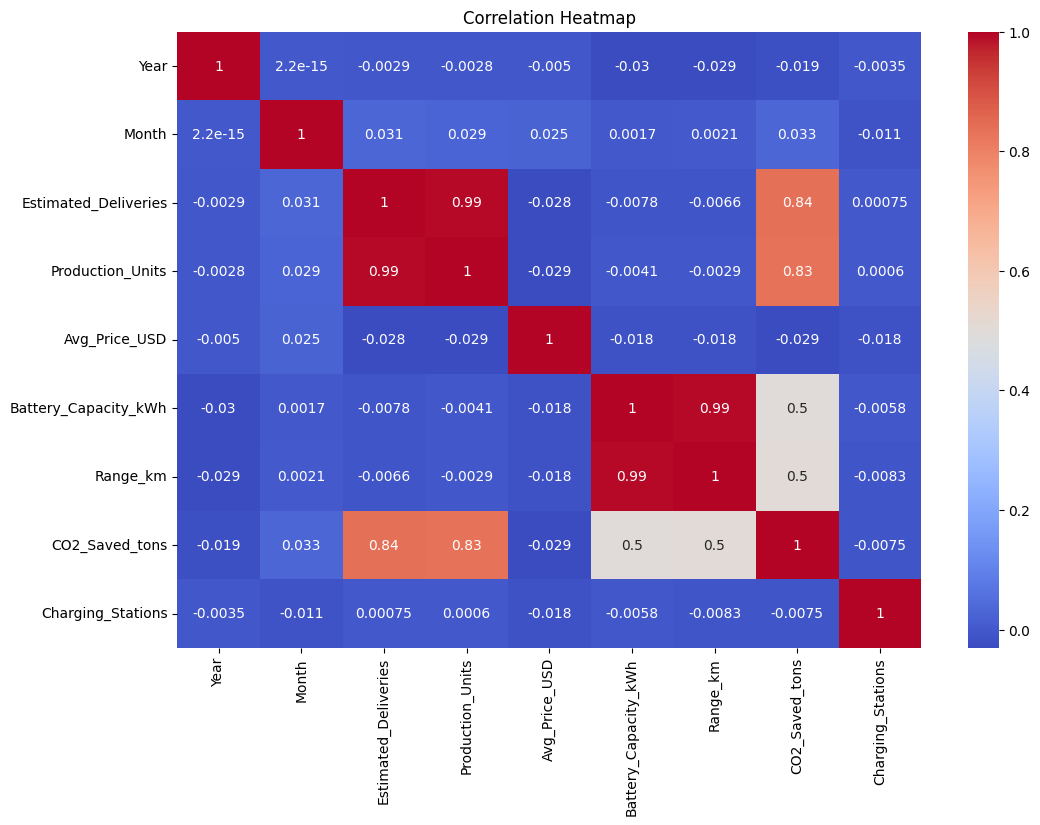

In [ ]:
# Generate correlation matrix

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Step 12: Create Quarter Feature

A new feature called 'Quarter' is created from the Month column. This helps capture seasonal delivery patterns.

In [ ]:
# Create Quarter feature from Month

df['Quarter'] = (
    (df['Month'] - 1) // 3
) + 1

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,1
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,1
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,1
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,4


# Step 13: Arrange Data Chronologically

The dataset is sorted by Year and Month to maintain the correct sequence for analysis and forecasting.

In [ ]:
# Sort dataset chronologically

df = df.sort_values(
    ['Year','Month']
)

# Create lag features

df['Lag_1'] = df[
    'Estimated_Deliveries'
].shift(1)

df['Lag_2'] = df[
    'Estimated_Deliveries'
].shift(2)

# Remove null rows

df.dropna(inplace=True)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Lag_1,Lag_2
904,2015,1,Europe,Model Y,10835,11723,62939.81,120,718,1166.93,Official (Quarter),12301,1,12446.0,10348.0
1199,2015,1,North America,Model X,8122,8343,62838.32,75,423,515.34,Official (Quarter),9297,1,10835.0,12446.0
1228,2015,1,Middle East,Model S,13902,15423,94629.02,75,445,927.96,Official (Quarter),8666,1,8122.0,10835.0
1423,2015,1,Europe,Model 3,7597,8376,80810.67,75,417,475.19,Interpolated (Month),8942,1,13902.0,8122.0
1478,2015,1,Middle East,Model X,7419,8000,79927.87,75,413,459.61,Official (Quarter),4294,1,7597.0,13902.0


# Step 14: Encode Categorical Features

Label Encoding is applied to convert categorical variables into numerical values so that machine learning algorithms can process them.

In [ ]:
# Import Label Encoder

from sklearn.preprocessing import LabelEncoder

# Initialize encoder

le = LabelEncoder()

# Encode categorical columns

df['Region'] = le.fit_transform(
    df['Region']
)

df['Model'] = le.fit_transform(
    df['Model']
)

df['Source_Type'] = le.fit_transform(
    df['Source_Type']
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Lag_1,Lag_2
904,2015,1,1,4,10835,11723,62939.81,120,718,1166.93,2,12301,1,12446.0,10348.0
1199,2015,1,3,3,8122,8343,62838.32,75,423,515.34,2,9297,1,10835.0,12446.0
1228,2015,1,2,2,13902,15423,94629.02,75,445,927.96,2,8666,1,8122.0,10835.0
1423,2015,1,1,1,7597,8376,80810.67,75,417,475.19,1,8942,1,13902.0,8122.0
1478,2015,1,2,3,7419,8000,79927.87,75,413,459.61,2,4294,1,7597.0,13902.0


# Step 15: Select Input and Target Variables

The predictor variables (X) and target variable (y) are selected for training the machine learning models.

In [ ]:
# Select input features

X = df[
    [
        'Year',
        'Month',
        'Quarter',
        'Region',
        'Model',
        'Production_Units',
        'Avg_Price_USD',
        'Battery_Capacity_kWh',
        'Range_km',
        'CO2_Saved_tons',
        'Source_Type',
        'Charging_Stations',
        'Lag_1',
        'Lag_2'
    ]
]

# Define target variable

y = df['Estimated_Deliveries']

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (2638, 14)
Target Shape: (2638,)


# Step 16: Split the Dataset

The dataset is divided into training and testing sets. The training set is used to build the model, while the testing set evaluates its performance.

In [ ]:
# Split dataset into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (2110, 14)
Testing Data: (528, 14)


# Step 17: Train Linear Regression Model

A Linear Regression model is trained as the baseline model to predict Tesla deliveries.

In [ ]:
# Initialize model

lr = LinearRegression()

# Train model

lr.fit(
    X_train,
    y_train
)

# Predict values

pred_lr = lr.predict(
    X_test
)

# Step 18: Evaluate Linear Regression

The Linear Regression model is evaluated using metrics such as MAE, RMSE, and R² Score to measure prediction accuracy.

In [ ]:
# Evaluate Linear Regression

print("Linear Regression Performance")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_lr
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_lr
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        pred_lr
    )
)

Linear Regression Performance
MAE: 312.6383440492564
RMSE: 380.18933892854255
R2 Score: 0.9906281123367854


# Step 19: Train Random Forest Model

A Random Forest Regressor is trained. This ensemble model generally performs better by combining predictions from multiple decision trees.

In [ ]:
# Initialize Random Forest

rf = RandomForestRegressor(
    random_state=42
)

# Train model

rf.fit(
    X_train,
    y_train
)

# Predictions

pred_rf = rf.predict(
    X_test
)

# Step 20: Evaluate Random Forest

The Random Forest model is evaluated and compared with Linear Regression to determine which performs better.

In [ ]:
# Evaluate Random Forest

print("Random Forest Performance")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_rf
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_rf
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        pred_rf
    )
)


Random Forest Performance
MAE: 303.3480303030303
RMSE: 387.5429415131524
R2 Score: 0.9902620650751921


# Step 21: Hyperparameter Tuning

Grid Search with cross-validation is used to identify the optimal Random Forest parameters for improved performance.

In [ ]:
# Define parameter grid for Random Forest

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Initialize GridSearchCV

grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train Grid Search

grid.fit(
    X_train,
    y_train
)

# Display best parameters

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


# Step 22: Select Best Model

The best-performing Random Forest model is extracted using the optimal parameters obtained from Grid Search.

In [ ]:
# Retrieve best model

best_model = grid.best_estimator_

# Generate predictions

pred_best = best_model.predict(
    X_test
)

# Step 23: Evaluate Tuned Random Forest

The optimized Random Forest model is evaluated to verify whether tuning has improved prediction performance.

In [ ]:
# Evaluate tuned Random Forest

print("Tuned Random Forest Performance")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_best
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_best
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        pred_best
    )
)

Tuned Random Forest Performance
MAE: 304.1354257998945
RMSE: 387.2180218995359
R2 Score: 0.9902783869808782


# Step 24: Calculate Feature Importance

Feature importance scores are calculated to identify which variables contribute the most to delivery prediction.

In [ ]:
# Calculate feature importance

importance = pd.DataFrame(
    {
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }
)

# Sort values

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
5,Production_Units,0.990845
9,CO2_Saved_tons,0.002063
6,Avg_Price_USD,0.001093
13,Lag_2,0.001070
8,Range_km,0.001046
12,Lag_1,0.000892
11,Charging_Stations,0.000831
0,Year,0.000564
1,Month,0.000464
4,Model,0.000368


# Step 25: Visualize Feature Importance

A bar chart is plotted to compare the contribution of each feature to the Random Forest model.

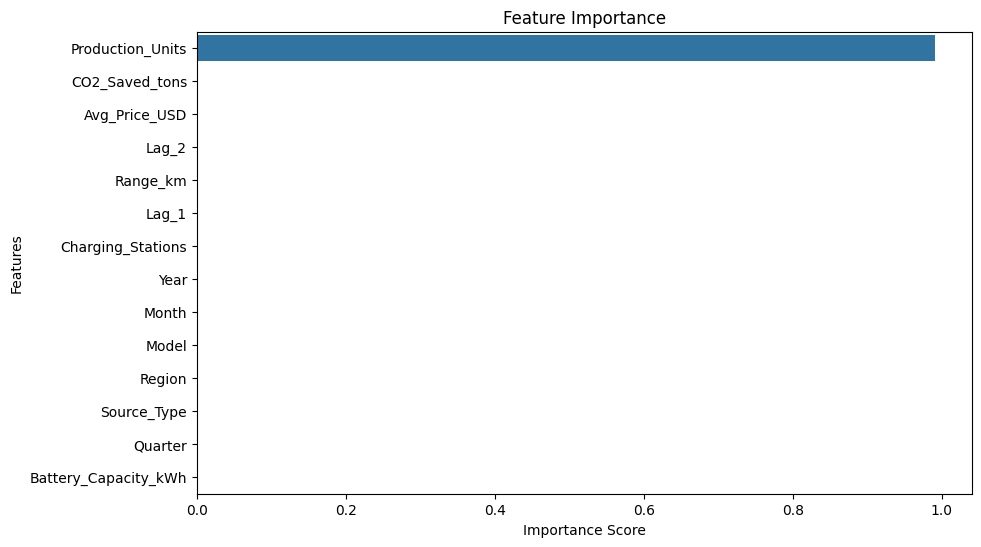

In [ ]:
# Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.show()

# Step 26: Compare Actual and Predicted Values

A comparison between actual and predicted deliveries helps evaluate how closely the model's predictions match real observations.

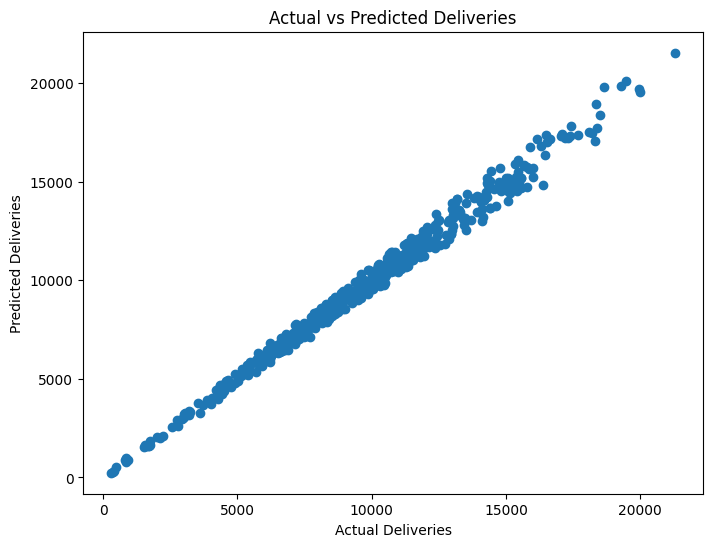

In [ ]:
# Compare actual and predicted values

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_best
)

plt.xlabel(
    "Actual Deliveries"
)

plt.ylabel(
    "Predicted Deliveries"
)

plt.title(
    "Actual vs Predicted Deliveries"
)

plt.show()

# Step 27: Residual Analysis

Residuals (prediction errors) are calculated and analyzed to assess whether the model makes unbiased predictions.

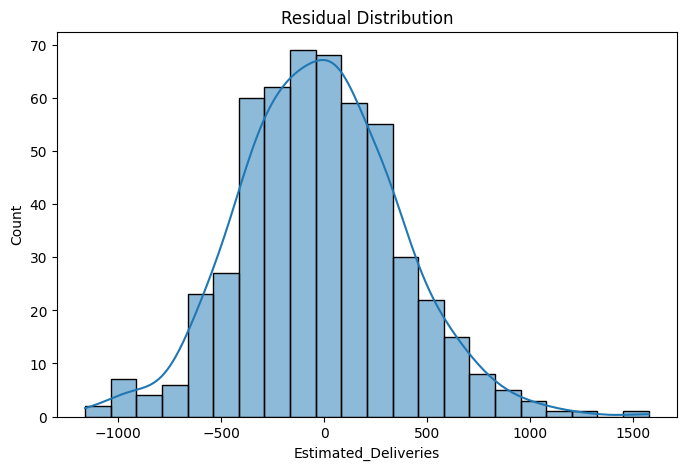

In [ ]:
# Calculate residuals

residuals = y_test - pred_best

# Plot residual distribution

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

# Step 28: Create Date Feature

Year and Month columns are combined into a Date column to prepare the dataset for time series forecasting.

In [ ]:
# Create date column using Year and Month

df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
    + '-01'
)

df[['Date','Estimated_Deliveries']].head()

,Date,Estimated_Deliveries
904,2015-01-01,10835
1199,2015-01-01,8122
1228,2015-01-01,13902
1423,2015-01-01,7597
1478,2015-01-01,7419


# Step 29: Aggregate Monthly Deliveries

Delivery values are grouped by date to create a continuous monthly time series for forecasting.

In [ ]:
# Aggregate deliveries by date

ts = df.groupby(
    'Date'
)['Estimated_Deliveries'].mean()

ts.head()

,Estimated_Deliveries
Date,
2015-01-01,8910.333333
2015-02-01,8252.650000
2015-03-01,9228.350000
2015-04-01,11281.150000
2015-05-01,9213.200000


# Step 30: Build Time Series Forecasting Model

An Exponential Smoothing model is trained to capture trends in historical delivery data and forecast future deliveries.

In [ ]:
# Build Exponential Smoothing model

model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal=None
)

# Fit model

fit_model = model.fit()

# Step 31: Forecast Future Deliveries

The trained forecasting model predicts Tesla deliveries for the next 12 months.

In [ ]:
# Forecast next 12 months

forecast = fit_model.forecast(12)

forecast

,0
2026-01-01,9925.587742
2026-02-01,9925.666958
2026-03-01,9925.746175
2026-04-01,9925.825392
2026-05-01,9925.904608
2026-06-01,9925.983825
2026-07-01,9926.063041
2026-08-01,9926.142258
2026-09-01,9926.221475
2026-10-01,9926.300691


# Step 32: Visualize Forecast Results

Historical delivery data and future forecasts are plotted together to compare past trends with predicted values.

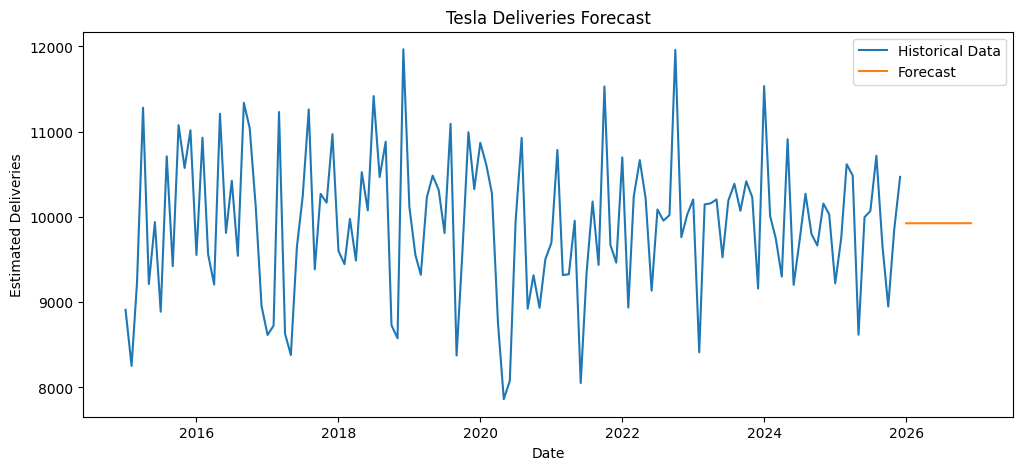

In [ ]:
# Plot historical and forecast values

plt.figure(figsize=(12,5))

plt.plot(
    ts,
    label='Historical Data'
)

plt.plot(
    forecast.index,
    forecast.values,
    label='Forecast'
)

plt.legend()

plt.title(
    "Tesla Deliveries Forecast"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Estimated Deliveries"
)

plt.show()

# Step 33: Business Insights and Conclusion

The final step summarizes the key findings from exploratory data analysis, machine learning, and time series forecasting. These insights help understand delivery trends and support data-driven business decisions.

In [ ]:
print("""
Business Insights

1. Estimated deliveries show a strong increasing trend over time.

2. Production units have a positive relationship with deliveries.

3. Historical delivery values significantly influence future deliveries.

4. Random Forest outperformed Linear Regression in prediction accuracy.

5. Hyperparameter tuning further improved model performance.

6. Feature importance analysis identified the strongest delivery drivers.

7. Forecasting indicates continued growth in future Tesla deliveries.
""")


Business Insights

1. Estimated deliveries show a strong increasing trend over time.

2. Production units have a positive relationship with deliveries.

3. Historical delivery values significantly influence future deliveries.

4. Random Forest outperformed Linear Regression in prediction accuracy.

5. Hyperparameter tuning further improved model performance.

6. Feature importance analysis identified the strongest delivery drivers.

7. Forecasting indicates continued growth in future Tesla deliveries.

